In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_log(file_path):
    # Load the log file
    df = pd.read_csv(file_path)
    
    # Group by UGV and calculate metrics
    results = {}
    for ugv, group in df.groupby('ugv'):
        task_count = len(group)
        time_intervals = group['timestep'].diff().dropna()
        avg_time = time_intervals.mean() if len(time_intervals) > 0 else 0
        
        results[ugv] = {
            'task_count': task_count,
            'avg_time_per_task': avg_time,
            'first_task_time': group['timestep'].min(),
            'last_task_time': group['timestep'].max()
        }
    
    return results

def compare_logs(log1_path, log2_path, log1_name="Simulation 1", log2_name="Simulation 2"):
    # Analyze both logs
    log1_results = analyze_log(log1_path)
    log2_results = analyze_log(log2_path)
    
    # Combine UGV IDs from both logs
    all_ugvs = set(log1_results.keys()).union(set(log2_results.keys()))
    
    # Create comparison table
    comparison = []
    for ugv in sorted(all_ugvs):
        row = {
            'UGV': ugv,
            f'Tasks ({log1_name})': log1_results.get(ugv, {}).get('task_count', 0),
            f'Tasks ({log2_name})': log2_results.get(ugv, {}).get('task_count', 0),
            f'Avg Time ({log1_name})': log1_results.get(ugv, {}).get('avg_time_per_task', 0),
            f'Avg Time ({log2_name})': log2_results.get(ugv, {}).get('avg_time_per_task', 0),
        }
        comparison.append(row)
    
    return pd.DataFrame(comparison)

# Usage example:
df_comparison = compare_logs('runs/tmp_log.csv', 'runs/tmp1_log.csv')
print(df_comparison)

   UGV  Tasks (Simulation 1)  Tasks (Simulation 2)  Avg Time (Simulation 1)  \
0    0                     5                     7                17.500000   
1    1                     7                     8                10.000000   
2    2                     7                    13                10.666667   

   Avg Time (Simulation 2)  
0                12.166667  
1                 7.714286  
2                 7.000000  


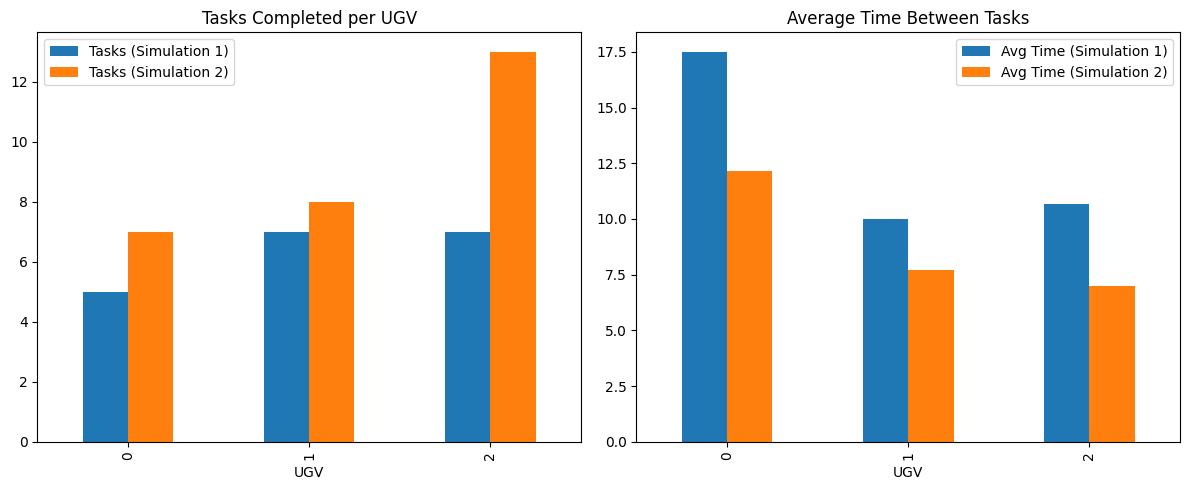

In [3]:
def visualize_comparison(comparison_df, log1_name="Simulation 1", log2_name="Simulation 2"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Task count comparison
    comparison_df.plot(x='UGV', y=[f'Tasks ({log1_name})', f'Tasks ({log2_name})'], 
                      kind='bar', ax=ax1, title='Tasks Completed per UGV')
    
    # Average time comparison
    comparison_df.plot(x='UGV', y=[f'Avg Time ({log1_name})', f'Avg Time ({log2_name})'], 
                      kind='bar', ax=ax2, title='Average Time Between Tasks')
    
    plt.tight_layout()
    plt.show()

# Usage:
visualize_comparison(df_comparison)